In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from matplotlib.colors import LinearSegmentedColormap

In [7]:
ds = pd.read_csv("/content/Customer_Behaviour.csv")

In [8]:
ds.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
ds = pd.get_dummies(ds, columns=["Gender"])

In [10]:
ds.head()

,User ID,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,15624510,19,19000,0,False,True
1,15810944,35,20000,0,False,True
2,15668575,26,43000,0,True,False
3,15603246,27,57000,0,True,False
4,15804002,19,76000,0,False,True


In [11]:
X = ds.iloc[:, [0,1,2,4,5]]
y = ds.iloc[:, [3]]

In [12]:
X

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,19,19000,False,True
1,15810944,35,20000,False,True
2,15668575,26,43000,True,False
3,15603246,27,57000,True,False
4,15804002,19,76000,False,True
...,...,...,...,...,...
395,15691863,46,41000,True,False
396,15706071,51,23000,False,True
397,15654296,50,20000,True,False
398,15755018,36,33000,False,True


In [13]:
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25)

In [26]:
tree = DecisionTreeClassifier(random_state=23)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=23)

In [27]:
y_pred = tree.predict(X_test)

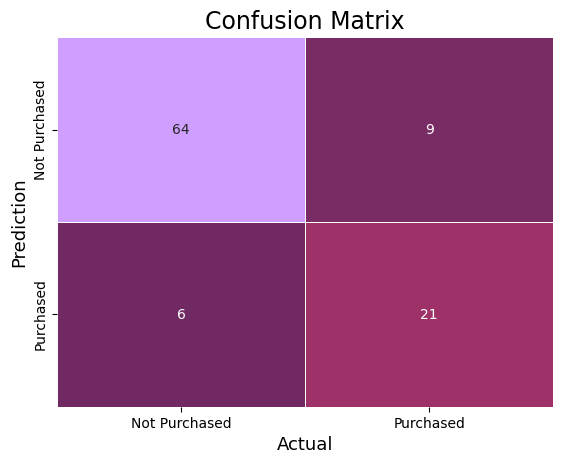

In [34]:
cmap = LinearSegmentedColormap.from_list("teal_purple", ['#702963', '#AA336A', '#DA70D6', '#CF9FFF'], N=256)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'],
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor='white'
           )

plt.ylabel('Prediction', fontsize=13)
plt.xlabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17)
plt.show()

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
F1_score = f1_score(y_test, y_pred)
print("F1-score:", F1_score)

Accuracy: 0.85
Precision: 0.7
Recall: 0.7777777777777778
F1-score: 0.7368421052631579
